In [49]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [50]:
# We import the clean DataFrame created in the previous assignment.
clean_df = pd.read_csv("clean_seattle_vancouver_weather.csv")

To get a grisp about the precipitation of both cities, draw a lineplot.

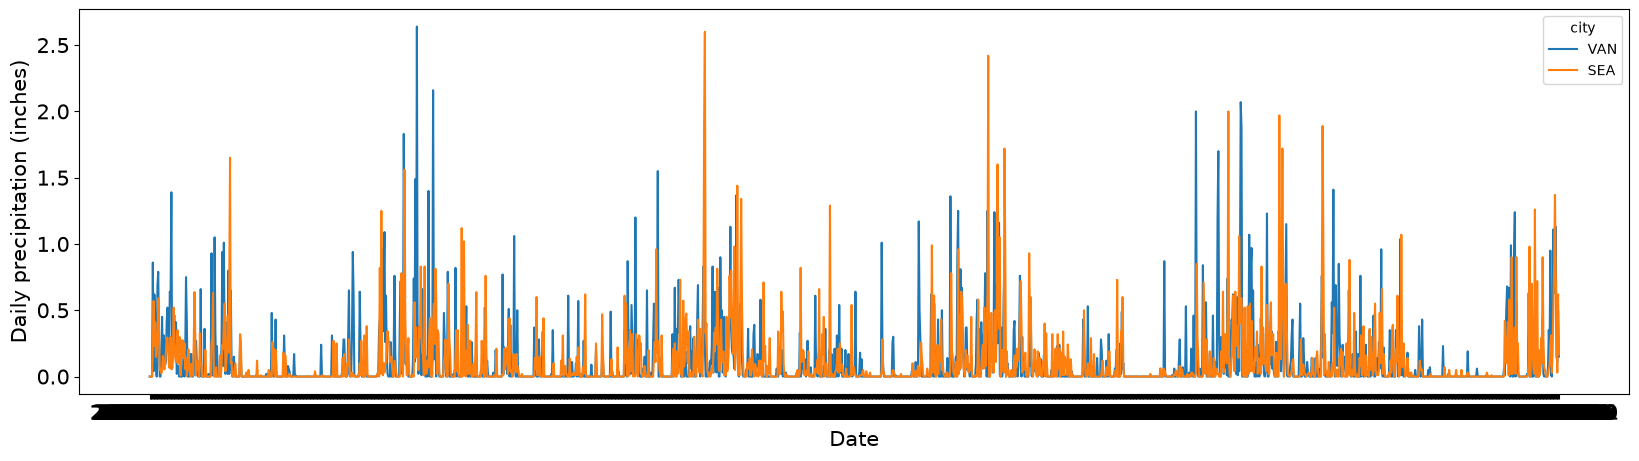

In [51]:
plt.figure(figsize=(20,5))

sns.lineplot(data=clean_df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

This line plot shows daily precipitation. 
The orange line represents precipitation in Seattle, while the blue line represents precipitation in Vancouver.

To examine the overall descriptive statistics of the dataset, I used describe().

In [52]:
clean_df[['city','precipitation']].groupby('city').describe()

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60
VAN         1826.0  0.122128  0.258779  0.0  0.0  0.00  0.13  2.64

The descriptive statistics show that Seattle and Vancouver have similar means, standard deviations, and percentiles for precipitation.

To visualize the mean precipitation for each city, I created a a bar plot.
Since sns.barplot uses the mean as its default estimator, I didn't specify the estimator explicitly.

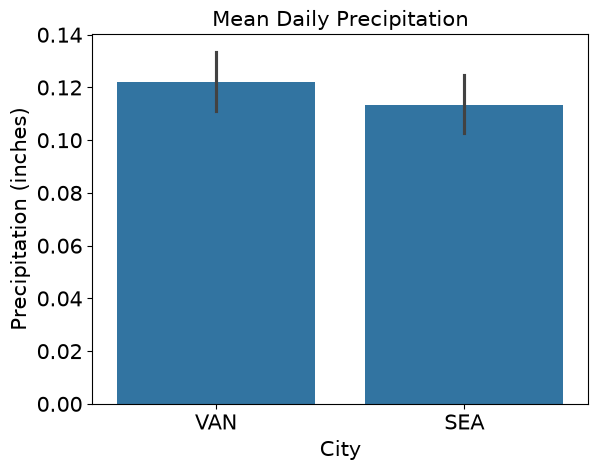

In [53]:
sns.barplot(data=clean_df, x='city', y='precipitation')

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('City', fontsize=15)
plt.title('Mean Daily Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

The graph shows that the overall mean daily precipitation is similar between the two cities.
To examine the data in more detail, I will look at precipitation by month.

# Precipitation by month

Add a column to the data frame with the number of the month

In [54]:
clean_df['month'] = pd.DatetimeIndex(clean_df['date']).month
clean_df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,VAN,0.00,1,1
1,2018-01-02,VAN,0.00,2,1
2,2018-01-03,VAN,0.00,3,1
3,2018-01-04,VAN,0.00,4,1
4,2018-01-05,VAN,0.86,5,1


I used box plots to examine the distribution of precipitation for each month. Since precipitation data contains many zero values, a bar plot showing only the mean does not provide a complete view of the data. Box plots allow us to examine the distribution and identify potential outliers.

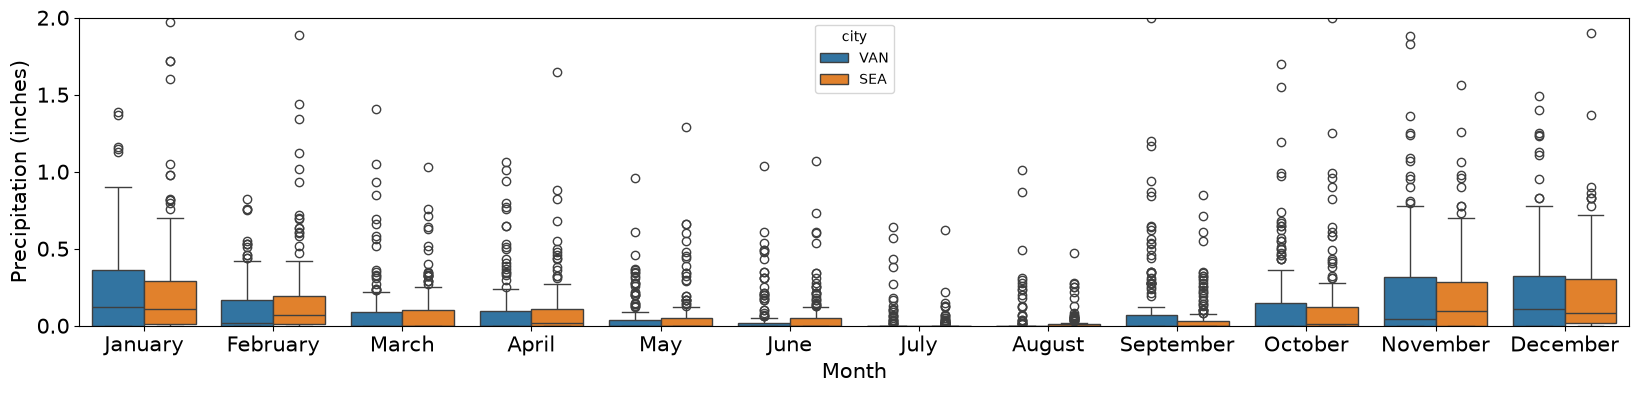

In [55]:
plt.figure(figsize=(20,4))

sns.boxplot(data=clean_df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.ylim(0, 2)

plt.show()


The graph shows that Seattle and Vancouver have similar seasonal precipitation patterns. Both cities receive more precipitation during the winter and less during the summer. The box plot shows that Seattle generally has a higher upper quartile of precipitation from February to June, while Vancouver has a higher upper quartile from September to January.

I computed the mean and standard deviation of precipitation for each month. I used unstack() to organize the results in a more readable format, making it easier to compare the values at a glance. Without unstack(), the table is too long and difficult to compare.

In [56]:
clean_df[['month', 'precipitation', 'city']].groupby(['city','month'])['precipitation'].agg(['mean','std']).unstack('city')


mean                 std          
city        SEA       VAN       SEA       VAN
month                                        
1      0.230742  0.246452  0.341816  0.335284
2      0.176472  0.116206  0.296935  0.183051
3      0.089075  0.094645  0.167194  0.206568
4      0.100483  0.105333  0.200652  0.210521
5      0.069161  0.053613  0.164036  0.126388
6      0.063167  0.059133  0.146171  0.144305
7      0.013984  0.023403  0.057169  0.087946
8      0.019995  0.033355  0.061337  0.125493
9      0.055622  0.119333  0.133198  0.274247
10     0.118452  0.141548  0.260078  0.282662
11     0.201867  0.237333  0.276785  0.391762
12     0.224903  0.235694  0.378504  0.367628

This table allows us to examine the patterns observed in the graph more precisely using numerical values.

Mean precipitation is generally higher during the winter and lower during the summer in both cities.

Particulary in September, Vancouver has about twice the mean precipitation and standard deviatoin of Seattle.

# Plot the proportion of days with any precipitation

Add a variable to the data frame that indicates whether there was any precipitation

In [57]:
clean_df['any_precipitation'] = clean_df['precipitation'] >0
clean_df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,VAN,0.00,1,1,False
1,2018-01-02,VAN,0.00,2,1,False
2,2018-01-03,VAN,0.00,3,1,False
3,2018-01-04,VAN,0.00,4,1,False
4,2018-01-05,VAN,0.86,5,1,True


Plot the proportion of days with any precipitation over the 5 years

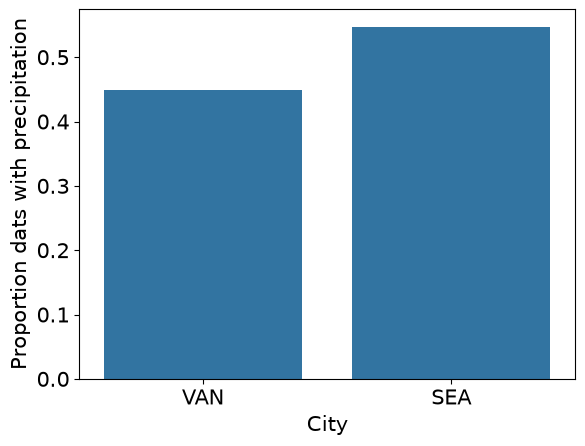

In [58]:
sns.barplot(data=clean_df, x='city', y='any_precipitation', errorbar=None)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion dats with precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

We can see that Seattle has a higher proportion days with precipitation.

Now, I want to examine the proportion of days with precipitation for each month. The bar plot below shows the proportion of days with precipitation by month.

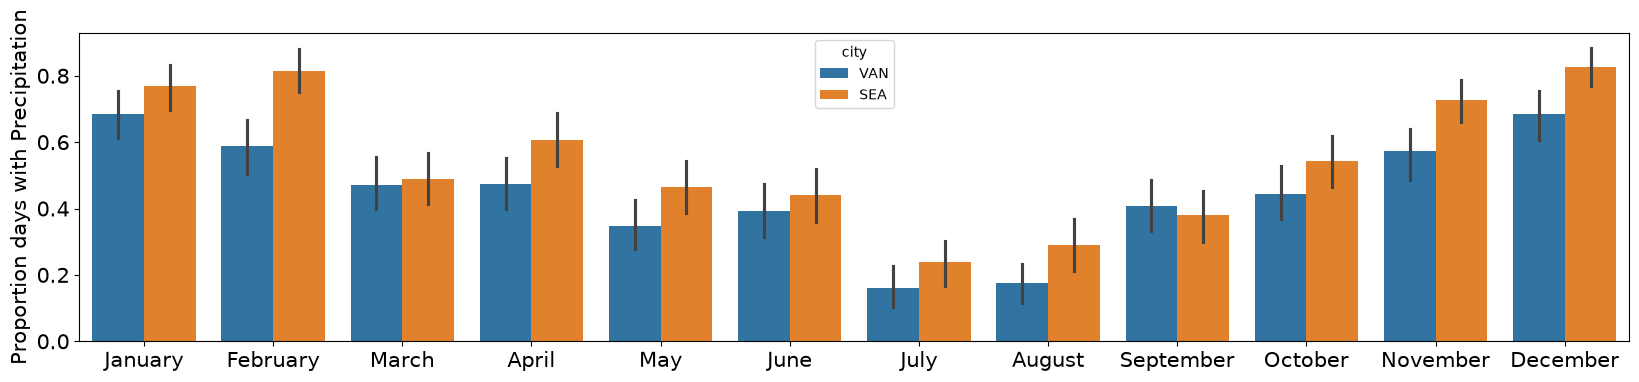

In [73]:
plt.figure(figsize=(20,4))

sns.barplot(data=clean_df, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion days with Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.show()


This bar plot shows that, except in August, the proportion of days with precipitation is higher in Seattle than Vancouver.

Below code draws a 12-panel histogram (one per month) comparing daily precipitation in Seattle and Vancouver, using identical 0.1-inch bins in every panel so the bars can be compared directly across months.

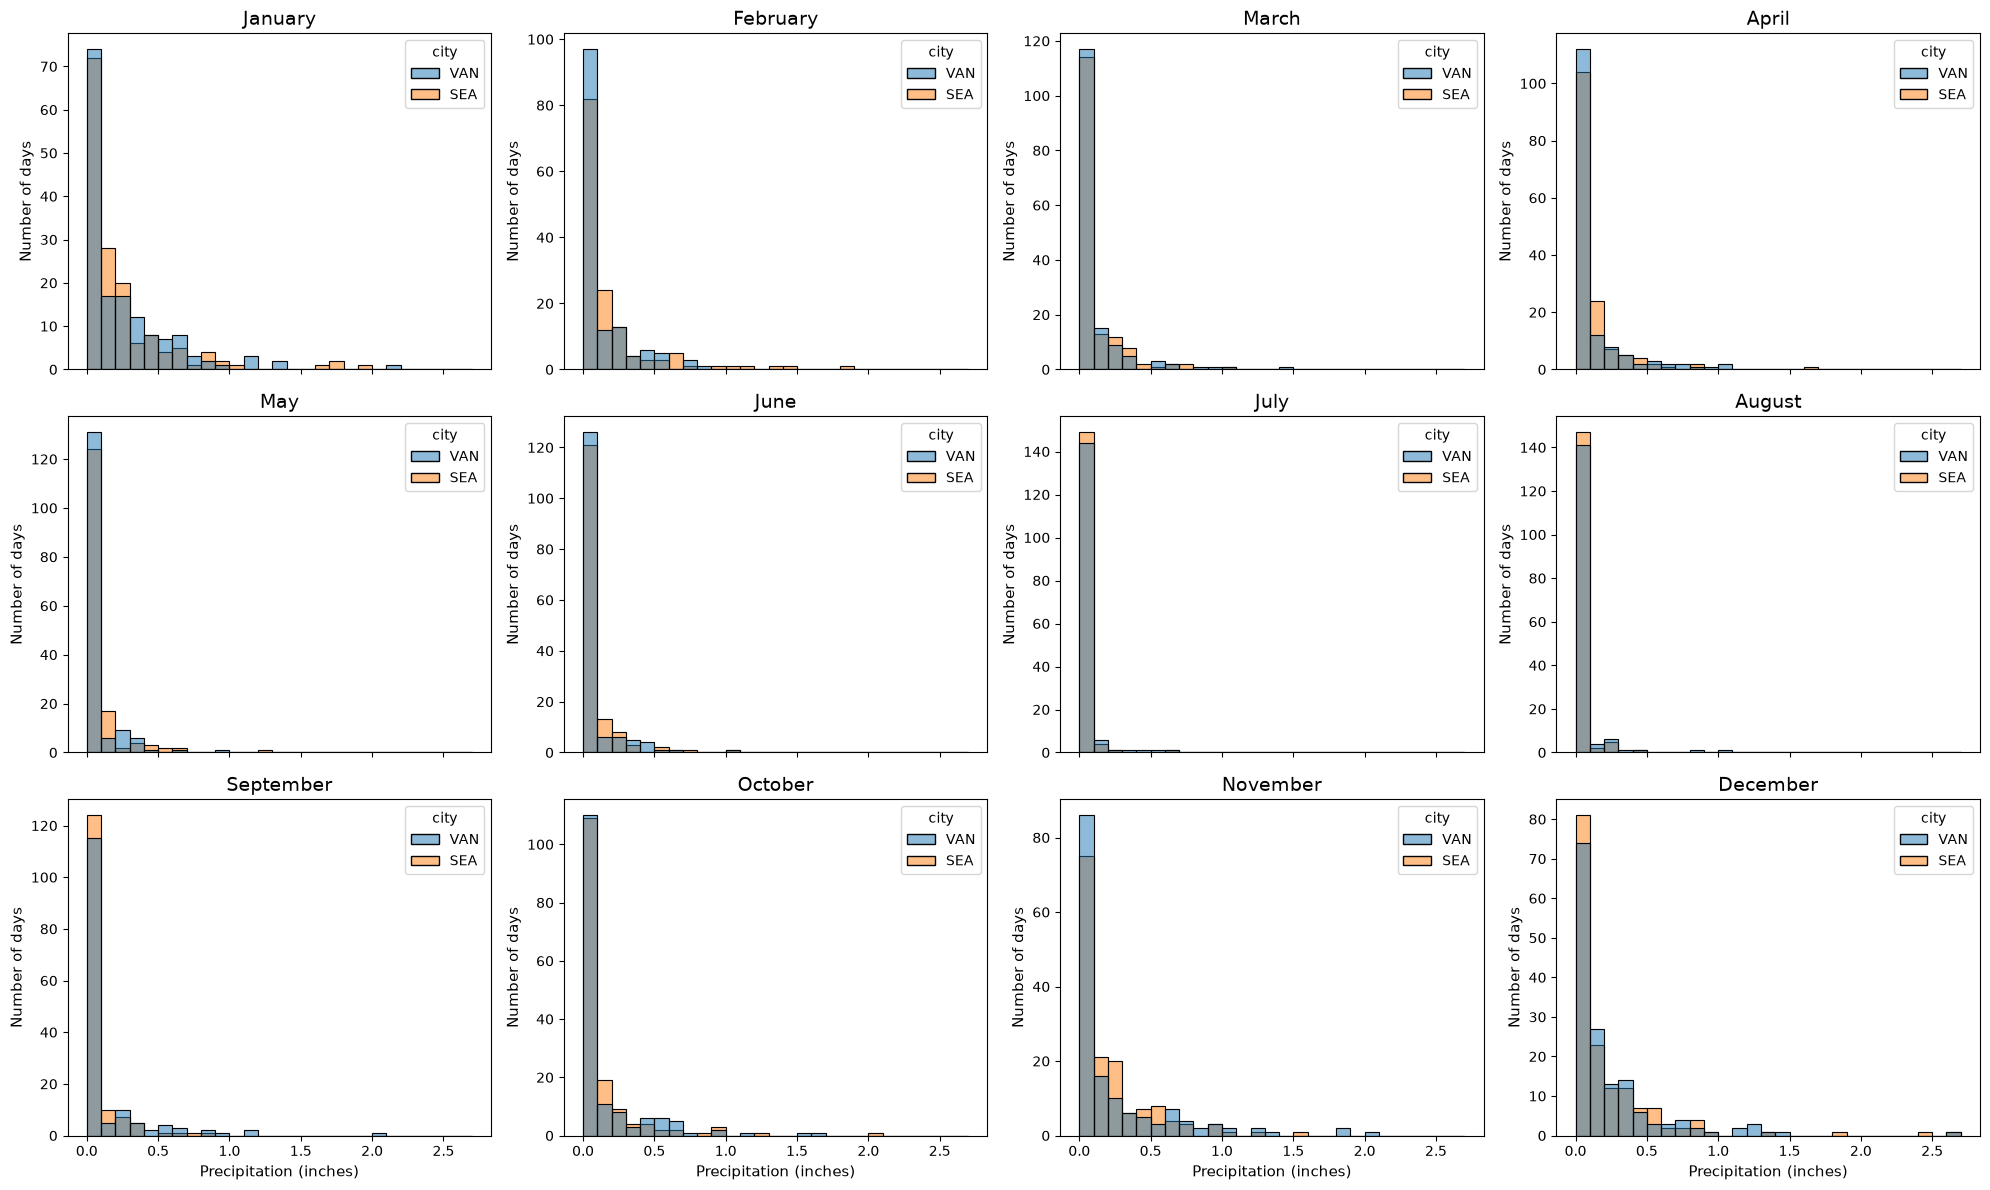

In [84]:
bin_width = 0.1
max_val = clean_df['precipitation'].max()
bins = np.arange(0, max_val + bin_width, bin_width)

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True)

for month, ax in zip(range(1, 13), axes.flat):
    sns.histplot(
        data=clean_df.loc[clean_df['month'] == month],
        x='precipitation',
        hue='city',
        bins=bins,          # same bins in every panel
        ax=ax
    )

    ax.set_title(calendar.month_name[month], fontsize=14)
    ax.set_xlabel('Precipitation (inches)', fontsize=11)
    ax.set_ylabel('Number of days', fontsize=11)

plt.tight_layout()
plt.show()

This graph shows the histogram of daily precipitation for the two cities over the year.
I think it gives a clearer picture, because a day with 0 to 0.1 inches of rain doesn't really feel different. The earlier graph counted any day with even a trace of rain, so it made the two cities look different while hiding how heavy the rain actually was.
Therefore Comparing the two shows how much of the difference comes from light rain. For example, the earlier graph shows a noticeable gap between the two cities in October, but here the 0 to 0.1 bin is almost the same height for both. This means the gap in the earlier graph came mostly from drizzle.

# Hypothesis Tests

Now I had visually explored the weather data, I am going to test with statistical methods.
First one is t-test.


In [63]:
significance_level = 0.05
significantly_different = np.zeros(12)

#perfrom t-test for each month
for month in range(1,13):
    #Get precipitation data for Seattle and Vancouver for the current month
    sea_data = clean_df.loc[(clean_df['city'] == 'SEA') & (clean_df['month'] == month), 'precipitation']
    van_data = clean_df.loc[(clean_df['city'] == 'VAN') & (clean_df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, van_data, equal_var = False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

        print(f"Month {month}:")
        print(f" t-statistic = {t_statistic:.2f}")
        print(f" p-value t test = {p_value:.3f}")
        print("-" * 20)
        

Month 2:
 t-statistic = 2.05
 p-value t test = 0.041
--------------------
Month 9:
 t-statistic = -2.56
 p-value t test = 0.011
--------------------


Using Welch's t-test on daily precipitation for each month, we rejected the null hypothesis of equal mean precipitation (p < 0.05) only in February and September. In the other ten months, we found no significant difference between the two cities' means.

Below is the visualization of the t-test.

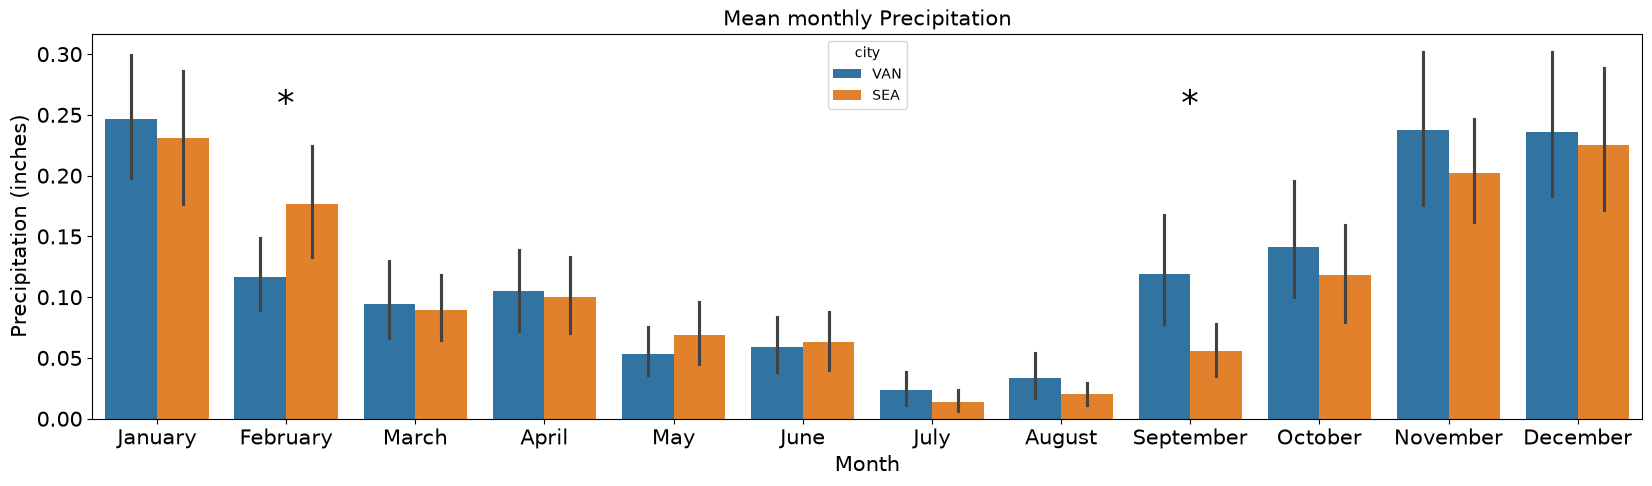

In [64]:
plt.figure(figsize=(20,5))

sns.barplot(data=clean_df, x='month', y='precipitation', hue='city', alpha=1)

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('Month', fontsize=15)
plt.title('Mean monthly Precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:
        #Add a star
        plt.text(month, 0.25, '*', ha='center', fontsize=25)
        
plt.show()

Months marked with * show a statistically significant difference in mean daily precipitation between Seattle and Vancouver (Welch's t-test, p < 0.05).

We now run a two-proportion z-test for each month to check whether the proportion of rainy days differs significantly between Seattle and Vancouver.

In [88]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Perform t-test for each month
for month in range(1,13):

    #Create a contingency table for Seattle and Vancouver for the current month:
    contingency_table = pd.crosstab(
        clean_df.loc[clean_df['month'] == month, 'city'], clean_df.loc[clean_df['month'] == month, 'any_precipitation']
    )

    # Calculate the number of True values (days with precipitation) for each city
    days_with_precipitation = contingency_table[True]

    #Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)

    #Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

        print(f"Month {month}:")
        print(f" z-statistic = {zstat:.2f}")
        print(f" p-value z test = {p_value:.3f}")
        print("-" * 20)
    

    

Month 2:
 z-statistic = 4.17
 p-value z test = 0.000
--------------------
Month 4:
 z-statistic = 2.32
 p-value z test = 0.021
--------------------
Month 5:
 z-statistic = 2.08
 p-value z test = 0.037
--------------------
Month 8:
 z-statistic = 2.42
 p-value z test = 0.015
--------------------
Month 11:
 z-statistic = 2.78
 p-value z test = 0.005
--------------------
Month 12:
 z-statistic = 2.90
 p-value z test = 0.004
--------------------


The two-proportion z-test shows that the share of rainy days differs between Seattle and Vancouver in 6 of 12 months (February, April, May, August, November, December). In every one of these months Seattle has the higher share. Especially in February, Seattle has a higher rainy-day frequency than Vancouver (z = 4.17). By contrast, the t-test on mean precipitation found a difference in only two months (February and September). This suggests that the two cities differ more in how often it rains than in how much rain falls in total.

To visualize the z test, below is the bar plot with the test results.

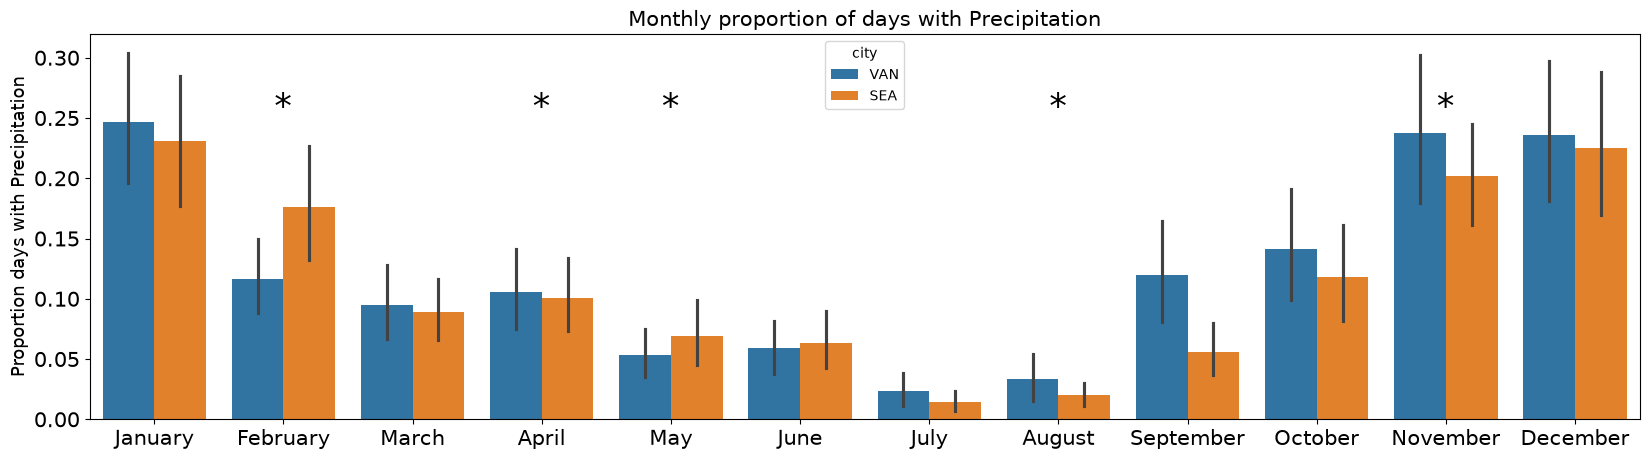

In [67]:
plt.figure(figsize=(20,5))

sns.barplot(data=clean_df, x='month', y='precipitation', hue='city', alpha=1)

plt.ylabel('Proportion days with Precipitation', fontsize=13)
plt.xlabel(None)
plt.title('Monthly proportion of days with Precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different_proportion[month] == 1:
        #Add a star
        plt.text(month, 0.25, '*', ha='center', fontsize=25)
        
plt.show()

This graph highlights the months with a significant difference in the proportion of rainy days between Seattle and Vancouver.